# Data Collection and Preparation - Health Emergencies Preparedness and Response Program (HEPR)

This notebook is a template workflow to collect data and prepare the main data to perform a baseline physical accessibility analysis to health facilities. It uses various tools developed by the World Bank's Geospatial Operations Support Team (GOST).

This notebook focuses on a raster-based implementation of market access, using the motorized Global Friction Surface from the [Malaria Atlas Project](https://malariaatlas.org/project-resources/accessibility-to-healthcare/).
Additionaly, it uses population data from [World Pop](https://hub.worldpop.org/project/categories?id=3) (Unconstrained UN-Adjusted 2020, 1km resolution).

## Data Download Links
- [World Pop Raster](https://data.worldpop.org/GIS/Population/Global_2000_2020_1km/2020/)
- [Friction Surface](https://malariaatlas.org/geoserver/ows?service=CSW&version=2.0.1&request=DirectDownload&ResourceId=Explorer:2020_motorized_travel_time_to_healthcare)

## 0. Setup

Import packages required for the analysis

In [86]:
import sys
import os
from os.path import join, expanduser
import geopandas as gpd
import pandas as pd
from gadm import GADMDownloader
from tqdm import tqdm

In [87]:
# Visualization tools
# import folium as flm
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from rasterio.plot import plotting_extent
from rasterio.plot import show
from mpl_toolkits.axes_grid1 import make_axes_locatable
import contextily as ctx
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [88]:
# Raster
import rasterio as rio
from rasterstats import zonal_stats
import numpy as np
from shapely.geometry import Polygon, box, Point
import skimage.graph as graph

# Graph
import pickle
import networkx as nx
import osmnx as ox

In [89]:
# Climate/Flood
import xarray as xr

In [90]:
# Define your path to the Repositories

sys.path.append(join(expanduser("~/OneDrive - WBG"), 'Repos', 'gostrocks', 'src'))
sys.path.append(join(expanduser("~/OneDrive - WBG"), 'Repos', 'GOSTNets_Raster', 'src'))
sys.path.append(join(expanduser("~/OneDrive - WBG"), 'Repos', 'GOSTnets'))
sys.path.append(join(expanduser("~/OneDrive - WBG"), 'Repos', 'GOST_Urban', 'src', 'GOST_Urban'))

import GOSTnets as gn
from GOSTnets.load_osm import *
import GOSTRocks.rasterMisc as rMisc
from GOSTRocks.misc import get_utm
import GOSTNetsRaster.market_access as ma
import UrbanRaster as urban

In [91]:
# auto reload
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Define below the local folder where you are located

In [92]:
scratch_dir = join(expanduser("~/OneDrive - WBG"), 'Health-Access-Metrics')
out_path = join(expanduser("~/OneDrive - WBG"), 'Health-Access-Metrics', 'Output')

## 1. Data Preparation

### Administrative boundaries

In [93]:
country = 'Malawi'
iso = 'MWI'
downloader = GADMDownloader(version="4.0")
adm0 = downloader.get_shape_data_by_country_name(country_name=country, ad_level=0)
adm1 = downloader.get_shape_data_by_country_name(country_name=country, ad_level=1)

### Population (origin)

In [94]:
# wp_path = join(expanduser("R:/"), 'Data', 'GLOBAL/Population/WorldPop_PPP_2020/MOSAIC_ppp_prj_2020', f'ppp_prj_2020_{iso}.tif') # Download from link above
wp_path = join(expanduser("R:/"), 'Data', 'GLOBAL/Population/WorldPop_PPP_2020', f'ppp_2020_1km_Aggregated.tif') # Download from link above

wp_rio = rio.open(wp_path)
pop_surf = rio.open(wp_path)

### Health Facilities (destinations)

In [95]:
hf_path = join(expanduser("~/OneDrive - WBG"), 'Health-Access-Metrics', 'data', 'MWI', 'HF_Malawi.xlsx')
df_hf = pd.read_excel(hf_path)
df_hf

,Facility Name,Village,GVH,TA,District,Region,Eastings,Northings,Datum,Facility Type,Controlling Agency,Name,Phone,Email,Cluster,Status,Date
0,CHITIPA DH,Mkombanyama,Mkombanyama,Mwawulambya,Chitipa,North,33.265889,-9.701577,WGS 84,Hospital,MoH,Dzinkambani Kambalame,991183141,dzinkambalame@gmail.com,Chitipa DH,Functional,2016-07-01
1,NGOYA,Mphala,Mwakawanga,Mwawulambya,Chitipa,North,33.293329,-9.617792,WGS 84,Health Post,MoH,Martha Mwanza,884254076,NaN,Chitipa DH,Functional,2016-07-01
2,KALIRA,Flyson,Mwanisenga,Mwawulambya,Chitipa,North,33.312223,-9.575143,WGS 84,Outreach,MoH,Jonathan Muyila,991818899,NaN,Chitipa DH,Functional,2016-07-01
3,KALIRA,Flyson,Mwanisenga,Mwawulambya,Chitipa,North,33.312223,-9.575143,WGS 84,Village Clinic,MoH,Jonathan Muyila,991818899,NaN,Chitipa DH,Functional,2016-07-01
4,KALIRA,Flyson,Mwanisenga,Mwawulambya,Chitipa,North,33.312223,-9.575143,WGS 84,Health Post,MoH,Jonathan Muyila,991818899,NaN,Chitipa DH,Functional,2016-07-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9493,MLOLO,Chipondeni,Chipondeni,Mlolo,Nsanje,South,35.152560,-16.419711,WGS 84,Health Post,MoH,Charlie Mateyu,881148416,NaN,Mlolo,Functional,2016-09-01
9494,KHANA,Khana,Gatoma,Mlolo,Nsanje,South,35.179200,-16.377098,WGS 84,Outreach,MoH,Caroline Allan,888601487,NaN,Mlolo,Functional,2016-09-01
9495,KHANA,Khana,Gatoma,Mlolo,Nsanje,South,35.179200,-16.377098,WGS 84,Village Clinic,MoH,Caroline Allan,888601487,NaN,Mlolo,Functional,2016-09-01
9496,KANDODO,Gowoke,Gowoke,Mlolo,Nsanje,South,35.159567,-16.405433,WGS 84,Outreach,MoH,Charity Bramu,888595161,NaN,Mlolo,Functional,2016-09-01


#### Subset a Health Facility type 

In [96]:
# Define which category of Health Facility to consider for the analysis

import ipywidgets as widgets

hf_type = list(df_hf['Facility Type'].unique())

w = widgets.Dropdown(
    options = hf_type,
    description='Health Facilities:',
    value = 'Hospital',
    disabled=False,
)

display('Select a type of Health Facility to perform the analysis: ')
display(w)


'Select a type of Health Facility to perform the analysis: '

Dropdown(description='Health Facilities:', options=('Hospital', 'Health Post', 'Outreach', 'Village Clinic', '…

In [97]:
df_hf = df_hf.loc[df_hf['Facility Type'] == w.value]

# df_hf = df_hf.loc[df_hf['Facility Type'] == "Hospital"]

Convert the HF from pandas.Dataframe to Geopandas.dataframe

In [98]:
geodf_hf = gpd.GeoDataFrame(
    df_hf, geometry=gpd.points_from_xy(df_hf.Eastings, df_hf.Northings), crs="EPSG:4326"
)

# Clean the geopandas dataframe
geodf_hf = geodf_hf[['Facility Name', 'geometry']]
geodf_hf.loc[:, 'ID'] = df_hf.index

### Flood

Here, we import Fathom flood data (.tif) of fluvial floods with different return periods. \
This data represent and mimic the climate impact on infrastructure and the disruption of the accessibility to health facilities.  

In [99]:
# Define which Flood Return Time to consider for the analysis

import ipywidgets as widgets

flood_path = join(expanduser("R:/"), 'Data', 'GLOBAL','FLOOD_SSBN','v2_2019/malawi', 'fluvial_undefended')
w = widgets.Dropdown(
    options = os.listdir(flood_path),
    description='Flood RT:',
    value = 'FU_1in5.tif',
    disabled=False,
)

display('Select the Flood Return Period to perform the analysis:')
display(w)

'Select the Flood Return Period to perform the analysis:'

Dropdown(description='Flood RT:', index=6, options=('FU_1in10.tif', 'FU_1in100.tif', 'FU_1in1000.tif', 'FU_1in…

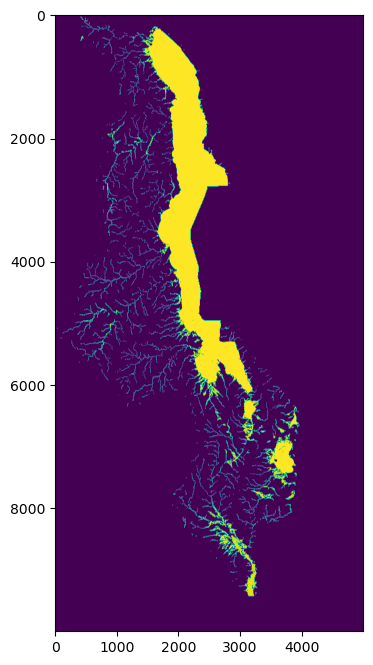

In [100]:
# Use rasterio to open the file
# inland waters and oceans: 999
# not-flooded areas: -9999
# Other values represent the flood depth (in  m)

flood_path = join(expanduser("R:/"), 'Data', 'GLOBAL','FLOOD_SSBN','v2_2019/malawi', 'fluvial_undefended', w.value)
flood_rio = rio.open(flood_path)

fig, ax = plt.subplots(figsize=(6,8))
im = ax.imshow(flood_rio.read(1), norm=colors.PowerNorm(gamma=0.5), cmap='viridis')

In [19]:
# Stack flood maps into a single rasterio multiband file

# # Read metadata of first file
# with rio.open(join(flood_path,files[0])) as src0:
#     meta = src0.meta

# # Update meta to reflect the number of layers
# meta.update(count = len(files))

# # Read each layer and write it to stack
# with rio.open('stack.tif', 'w', **meta) as dst:
#     for id, file in enumerate(files, start=1):
#         with rio.open(join(flood_path,file)) as src1:
#             dst.write_band(id, src1.read(1))

# flood_path = join(scratch_dir, 'notebooks', 'stack.tif')
# flood_rio = rio.open(flood_path)


### Friction Surface

Process the travel cost surface from the Malaria Atlas Project, clip the raster to our region of interest.

In [20]:
# # Only the first time, clip the travel friction surface to the country of interest

# gfs_path = join(expanduser("R:/"), 'Data', 'GLOBAL/INFRA/FRICTION_2020', '2020_motorized_friction_surface.geotiff') # Download from link above
# gfs_rio = rio.open(gfs_path)
# out_travel_surface = join(scratch_dir, 'data', f"travel_surface_motorized_{iso}.tif")
# rMisc.clipRaster(gfs_rio, adm0, out_travel_surface, crop=False)

In [102]:
# Import the clipped friction surface

out_travel_surface = join(scratch_dir, 'data', f"travel_surface_motorized_{iso}.tif")
travel_surf = rio.open(out_travel_surface)
travel_surf

<open DatasetReader name='C:/Users/wb618081/OneDrive - WBG/Health-Access-Metrics/data/travel_surface_motorized_MWI.tif' mode='r'>

In [103]:
print(travel_surf.res)
print(pop_surf.res)

(0.008333333333333333, 0.008333333333333333)
(0.0083333333, 0.0083333333)


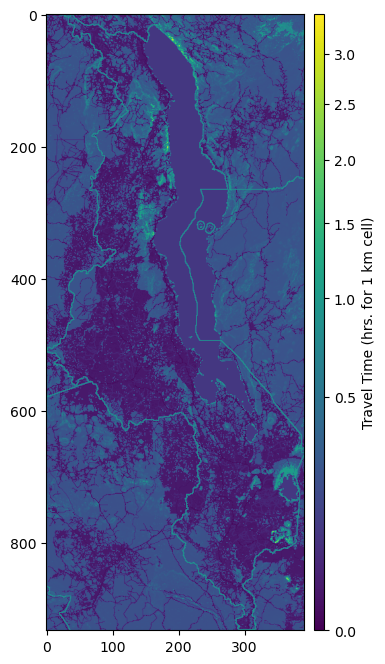

In [23]:
fig, ax = plt.subplots(figsize=(6,8))
im = ax.imshow(travel_surf.read(1)*1000/60, norm=colors.PowerNorm(gamma=0.5), cmap='viridis')
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size="4%", pad=0.1)
cb = fig.colorbar(im, cax=cax, orientation='vertical')
cb.set_label("Travel Time (hrs. for 1 km cell)")

Align the POPULATION raster to the friction surface, ensuring that they have the same extent and resolution.

In [74]:
out_pop_surface_std = join(scratch_dir, 'data', "WP_2020_1km_STD_test.tif")
rMisc.standardizeInputRasters(pop_surf, travel_surf, out_pop_surface_std, resampling_type="nearest")

[array([[[67.61455  , 70.83097  , 96.48191  , ...,  4.846376 ,
           7.727382 ,  7.5541716],
         [61.91576  , 62.618916 , 77.278244 , ...,  2.8063774,
           6.704942 ,  7.74414  ],
         [53.38135  , 55.781017 , 64.322914 , ...,  1.6051795,
           4.2656183,  4.0875587],
         ...,
         [32.477394 , 28.508108 , 25.174734 , ..., 15.47292  ,
          14.119669 , 12.792173 ],
         [30.201307 , 31.671202 , 31.06995  , ..., 16.121716 ,
          14.633034 , 13.378336 ],
         [33.76848  , 32.88883  , 32.243195 , ..., 14.960836 ,
          14.153514 , 13.6319685]]], dtype=float32),
 {'driver': 'GTiff',
  'dtype': 'float32',
  'nodata': -3.4028234663852886e+38,
  'width': 390,
  'height': 933,
  'count': 1,
  'crs': CRS.from_epsg(4326),
  'transform': Affine(0.008333333333333333, 0.0, 32.66666666666666,
         0.0, -0.008333333333333333, -9.358333333333334)}]

Align the FLOOD raster to the friction surface, ensuring that they have the same extent and resolution.

In [104]:
out_flood_std = join(scratch_dir, 'data', "STD_" + w.value)
rMisc.standardizeInputRasters(flood_rio, travel_surf, out_flood_std, resampling_type="nearest")

[array([[[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]]], dtype=float32),
 {'driver': 'GTiff',
  'dtype': 'float32',
  'nodata': None,
  'width': 390,
  'height': 933,
  'count': 1,
  'crs': CRS.from_epsg(4326),
  'transform': Affine(0.008333333333333333, 0.0, 32.66666666666666,
         0.0, -0.008333333333333333, -9.358333333333334)}]

### Origins

We prepare a standard grid using each cell from the 1km World Pop raster.

In [138]:
pop_surf = rio.open(out_pop_surface_std)
pop = pop_surf.read(1, masked=False)
pop_surf.read_crs()

CRS.from_epsg(4326)

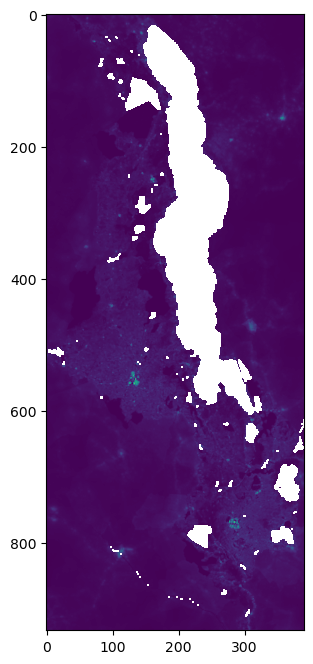

In [28]:
pop_copy = pop.copy()
pop_copy[pop_copy==0] = np.nan

fig, ax = plt.subplots(figsize=(6,8))
im = ax.imshow(pop_copy, norm=colors.PowerNorm(gamma=0.5), cmap='viridis')

In [77]:
indices = list(np.ndindex(pop.shape))
xys = [Point(pop_surf.xy(ind[0], ind[1])) for ind in indices]
res_df = pd.DataFrame({
    'spatial_index': indices,
    'xy': xys,
    'pop': pop.flatten()
})
res_df['pointid'] = res_df.index
res_df

,spatial_index,xy,pop,pointid
0,"(0, 0)",POINT (32.67083333333333 -9.3625),67.614548,0
1,"(0, 1)",POINT (32.67916666666666 -9.3625),70.830971,1
2,"(0, 2)",POINT (32.68749999999999 -9.3625),96.481911,2
3,"(0, 3)",POINT (32.695833333333326 -9.3625),111.579651,3
4,"(0, 4)",POINT (32.70416666666666 -9.3625),161.928329,4
...,...,...,...,...
363865,"(932, 385)",POINT (35.879166666666656 -17.129166666666666),32.535667,363865
363866,"(932, 386)",POINT (35.88749999999999 -17.129166666666666),24.958359,363866
363867,"(932, 387)",POINT (35.89583333333332 -17.129166666666666),14.960836,363867
363868,"(932, 388)",POINT (35.904166666666654 -17.129166666666666),14.153514,363868


### Flood impact on Friction Surface

In [106]:
flood_rio = rio.open(out_flood_std)
display(flood_rio.read_crs())
flood_rio = flood_rio.read(1, masked=False)

CRS.from_epsg(4326)

We consider different degrees of accessibility/mobility disruption according to different flood depth (FD) levels

- If the FD is less than 0.3 meters, than accessibility is preserved but signifcantly impacted (slowered)
- If the FD is higher than 0.3 meters, than mobility is interrupted on that specific pathway 

In [107]:
# Create weights for the Friction Surface
# If water level is less than 30 cm, accessibility is halved (travel time doubles)
# If water level is more than 30 cm, accessibility is disrupted (travel time *100)

flood_rio_fd = flood_rio.copy()

flood_rio_fd[(flood_rio <= 0) | (flood_rio == 999)] = 1
flood_rio_fd[(flood_rio > 0) & (flood_rio < 0.3)] = 2
flood_rio_fd[(flood_rio >= 0.3) & (flood_rio < 999)] = 100

# Check flood weight values
np.unique(flood_rio_fd)

array([  1.,   2., 100.], dtype=float32)

In [108]:
# Weight the Friction Surface with the discrete flood depth array

travel_surf_flood = travel_surf.read(1) * flood_rio_fd

Create an MCP graph object from the friction surface.

In [109]:
# convert friction surface to traversal time (lazily). Original data are minutes to travel 1 m:
# We convert it to minutes to cross the cell (1000m). This could be revised

inG_data = travel_surf_flood * 1000

# Correct no data values. Not needed but good to check
# inG_data[inG_data < 0] = 99999999
# inG_data[inG_data < 0] = np.nan
mcp = graph.MCP_Geometric(inG_data)

# Check the descriptive statistics
print(f"Mean: {np.mean(inG_data)}")
print(f"Max: {np.max(inG_data)}")
print(f"Min: {np.min(inG_data)}")
print(f"Std: {np.std(inG_data)}")

Mean: 16.2965145111084
Max: 9718.626953125
Min: 0.5
Std: 141.70745849609375


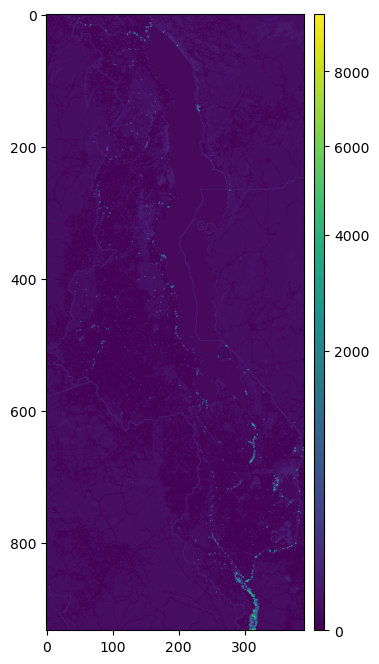

In [110]:
# Plot the Travel Time surface

copy = inG_data.copy()
copy[copy<0] = np.nan

fig, ax = plt.subplots(figsize=(6,8))
im = ax.imshow(copy, norm=colors.PowerNorm(gamma=0.5), cmap='viridis')
divider = make_axes_locatable(ax)

cax = divider.append_axes('right', size="4%", pad=0.1)
cb = fig.colorbar(im, cax=cax, orientation='vertical')

## 2. Data analysis

**Indicators of interest**

Percentage of population within 2h of driving to the nearest primary care facility (population level, and by SES quintile). \
Percentage of population within 2h of driving to the nearest district hospital (population, and by SES quintile). \
Percentage of health facilities with direct access to an all season road. \
Percentage of health facilities within 2km of an all season road.


In [83]:
len(res_df), len(geodf_hf)

(363870, 85)

Calculate the travel time from each grid-cell to the nearest destination

In [84]:
geodf_hf

,Facility Name,geometry,ID
0,CHITIPA DH,POINT (33.26589 -9.70158),0
214,KARONGA DH,POINT (33.91076 -9.95506),214
367,CHILUMBA,POINT (34.25147 -10.43240),367
442,ATUPELE,POINT (33.83755 -9.73631),442
458,KAPORO,POINT (33.87465 -9.76753),458
...,...,...,...
9061,MONTFORT,POINT (34.86908 -16.25632),9061
9229,NGABU,POINT (34.89222 -16.45934),9229
9272,NSANJE DH,POINT (35.25995 -16.91768),9272
9398,KALEMBA,POINT (35.11150 -16.57579),9398


In [114]:
res = ma.calculate_travel_time(travel_surf, mcp, geodf_hf)[0]
print(res)

print(len(res.flatten()), len(res_df))

[[ 205.36438346  203.86438346  195.77445864 ... 1164.36691006
  1177.355002   1190.44449098]
 [ 205.9857038   212.85261988  199.65060865 ... 1161.3602246
  1174.53651273 1187.94219863]
 [ 215.46197066  214.43606638  197.0513637  ... 1156.26292492
  1169.71982647 1183.41349913]
 ...
 [ 467.89505936  454.28047635  445.75496626 ...  317.83843903
   319.66243195  330.99885254]
 [ 462.50430844  448.86050627  434.97523377 ...  332.37147621
   332.79731297  338.27719316]
 [ 458.83065196  444.94388934  431.32569953 ...  345.89508204
   346.13903117  351.50123534]]
363870 363870


In [115]:
res_df.loc[:, 'tt_hf_min'] = res.flatten()
res_df

,spatial_index,xy,pop,pointid,tt_hf_min
0,"(0, 0)",POINT (32.67083333333333 -9.3625),67.614548,0,205.364383
1,"(0, 1)",POINT (32.67916666666666 -9.3625),70.830971,1,203.864383
2,"(0, 2)",POINT (32.68749999999999 -9.3625),96.481911,2,195.774459
3,"(0, 3)",POINT (32.695833333333326 -9.3625),111.579651,3,187.684534
4,"(0, 4)",POINT (32.70416666666666 -9.3625),161.928329,4,186.184534
...,...,...,...,...,...
363865,"(932, 385)",POINT (35.879166666666656 -17.129166666666666),32.535667,363865,348.091165
363866,"(932, 386)",POINT (35.88749999999999 -17.129166666666666),24.958359,363866,347.216239
363867,"(932, 387)",POINT (35.89583333333332 -17.129166666666666),14.960836,363867,345.895082
363868,"(932, 388)",POINT (35.904166666666654 -17.129166666666666),14.153514,363868,346.139031


In [116]:
# remove values where pop is 0 or nan
res_df = res_df.loc[res_df['pop']!=0].copy()
res_df = res_df.loc[~(res_df['pop'].isna())].copy()

res_df.loc[:,'xy'] = res_df.loc[:,'xy'].apply(lambda x: Point(x))

Create Geodataframe for the population grid

In [119]:
origins = gpd.GeoDataFrame(res_df, geometry='xy', crs='EPSG:4326')
origins

,spatial_index,xy,pop,pointid,tt_hf_min
0,"(0, 0)",POINT (32.67083 -9.36250),67.614548,0,205.364383
1,"(0, 1)",POINT (32.67917 -9.36250),70.830971,1,203.864383
2,"(0, 2)",POINT (32.68750 -9.36250),96.481911,2,195.774459
3,"(0, 3)",POINT (32.69583 -9.36250),111.579651,3,187.684534
4,"(0, 4)",POINT (32.70417 -9.36250),161.928329,4,186.184534
...,...,...,...,...,...
363865,"(932, 385)",POINT (35.87917 -17.12917),32.535667,363865,348.091165
363866,"(932, 386)",POINT (35.88750 -17.12917),24.958359,363866,347.216239
363867,"(932, 387)",POINT (35.89583 -17.12917),14.960836,363867,345.895082
363868,"(932, 388)",POINT (35.90417 -17.12917),14.153514,363868,346.139031


In [131]:
origins.rename(columns={'xy':'geometry'}, inplace=True)
origins.set_geometry('geometry', inplace=True)

# convert travel time to hours
origins.loc[:, "tt_hf_min_hrs"] = origins.loc[:, "tt_hf_min"] / 60

display(origins.head(2))
print(origins.crs)

,spatial_index,geometry,pop,pointid,tt_hf_min,tt_hf_min_hrs
0,"(0, 0)",POINT (32.67083 -9.36250),67.614548,0,205.364383,3.42274
1,"(0, 1)",POINT (32.67917 -9.36250),70.830971,1,203.864383,3.39774


EPSG:4326


Save results as raster

In [127]:
# tt_raster = join(scratch_dir, f"tt_hf_min_motorized_friction_{facility}.tif")
tt_raster = join(scratch_dir, f"tt_hf_min_motorized_friction_flood_test.tif")

rMisc.rasterizeDataFrame(
    inD = origins,
    outFile = tt_raster,
    idField = 'tt_hf_min_hrs',
    templateRaster = out_travel_surface
)

## Map Results

In [128]:
tt_rio = rio.open(tt_raster)
tt_rio = tt_rio

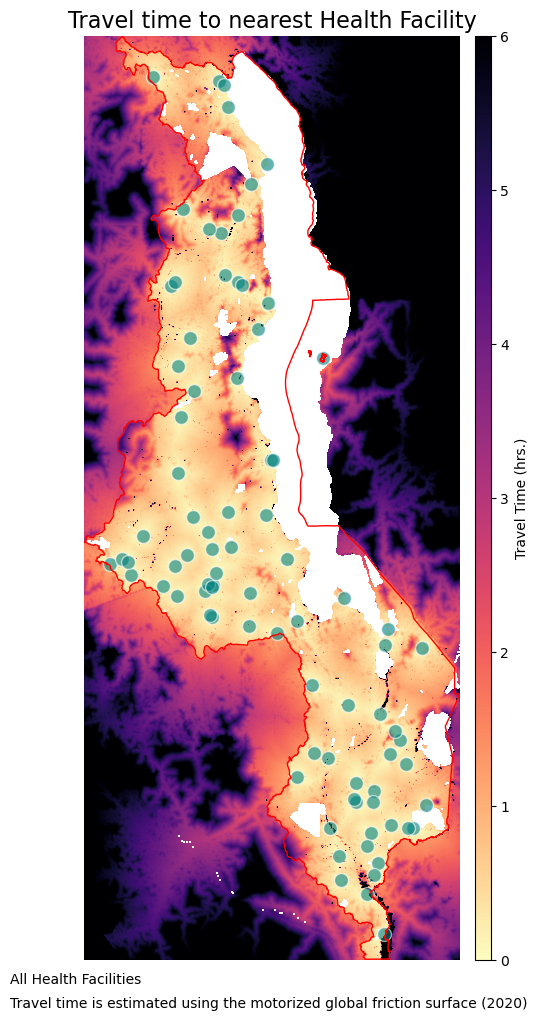

In [129]:
# Plot

figsize = (7, 12)
fig, ax = plt.subplots(1, 1,  figsize = figsize)
ax.set_title("Travel time to nearest Health Facility", fontsize=16, horizontalalignment='center')
plt.axis('off')
ext = plotting_extent(tt_rio)
im = ax.imshow(tt_rio.read(1), vmin=0, vmax=6, cmap='magma_r', extent=ext)
geodf_hf.plot(ax=ax, facecolor='teal', edgecolor='white', markersize=100, alpha=0.6)
adm0.plot(ax=ax, facecolor="none", edgecolor='red')
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size="4%", pad=0.1)
cb = fig.colorbar(im, cax=cax, orientation='vertical')
cb.set_label("Travel Time (hrs.)")
# ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, crs='EPSG:4326', zorder=-1)
txt="All Health Facilities"
txt2 = "Travel time is estimated using the motorized global friction surface (2020)"
plt.figtext(0.12, 0.09, txt, wrap=True, horizontalalignment='left', fontsize=10)
plt.figtext(0.12, 0.07, txt2, wrap=True, horizontalalignment='left', fontsize=10)
# plt.figtext(0.85, 0.76, "Travel Time (hrs.)", wrap=False, fontsize=10)
plt.savefig("travel-time-friction_flood5.png", dpi=300, bbox_inches='tight', facecolor='white')

## Flood effect on Health accessibility

In [134]:
tt_raster = join(scratch_dir, f"tt_hf_min_motorized_friction.tif")
tt_rio = rio.open(tt_raster).read(1)

tt_raster = join(scratch_dir, f"tt_hf_min_motorized_friction_flood_100.tif")
tt_rio_flood = rio.open(tt_raster).read(1)

Check the difference between flooded and not flooded scenarios 

In [93]:
flood_impact = tt_rio_flood - tt_rio

Text(0.12, 0.07, 'Travel time is estimated using the motorized global friction surface (2020)')

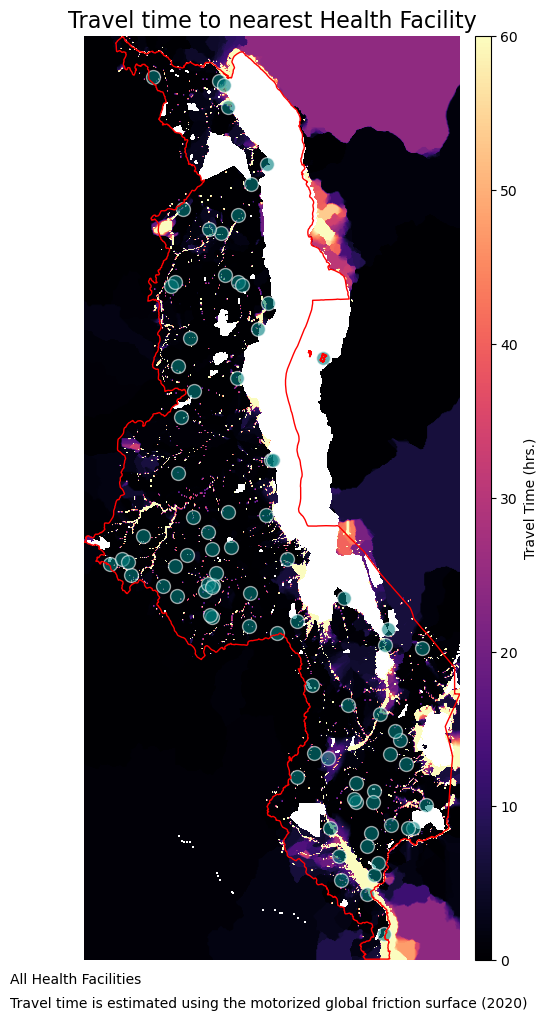

In [78]:
# Plot
import cartopy.feature as cfeature

figsize = (7, 12)
fig, ax = plt.subplots(1, 1,  figsize = figsize)
ax.set_title("Travel time to nearest Health Facility", fontsize=16, horizontalalignment='center')
plt.axis('off')
ext = plotting_extent(tt_rio)
im = ax.imshow(flood_impact*60, vmin=0, vmax=60, cmap='magma', extent=ext)
geodf_hf.plot(ax=ax, facecolor='teal', edgecolor='white', markersize=100, alpha=0.6)
adm0.plot(ax=ax, facecolor="none", edgecolor='red')

# ax.add_feature(cfeature.LAND)

divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size="4%", pad=0.1)
cb = fig.colorbar(im, cax=cax, orientation='vertical')
cb.set_label("Travel Time (hrs.)")
# ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, crs='EPSG:4326', zorder=-1)
txt="All Health Facilities"
txt2 = "Travel time is estimated using the motorized global friction surface (2020)"
plt.figtext(0.12, 0.09, txt, wrap=True, horizontalalignment='left', fontsize=10)
plt.figtext(0.12, 0.07, txt2, wrap=True, horizontalalignment='left', fontsize=10)
# plt.savefig("travel-time-friction_flood100.png", dpi=300, bbox_inches='tight', facecolor='white')

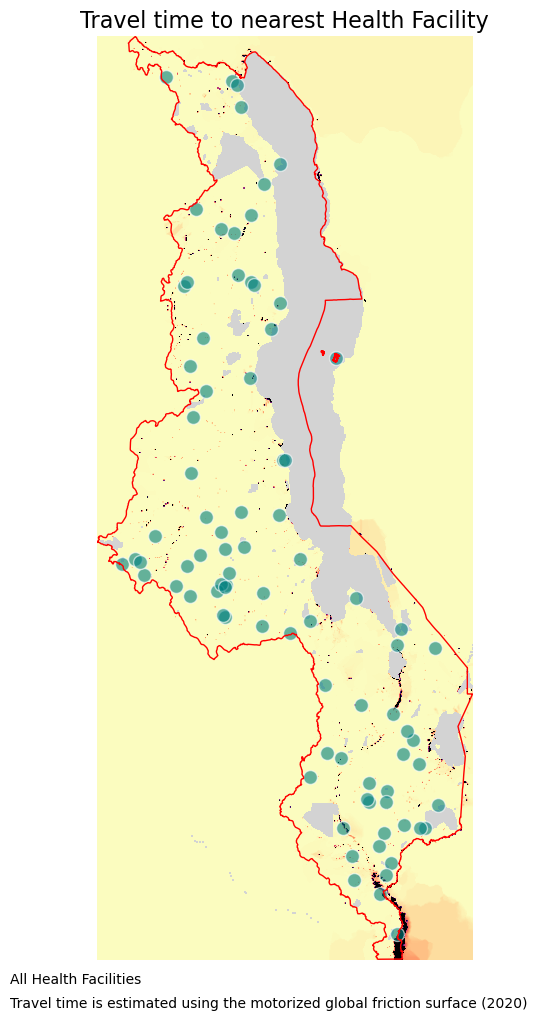

In [78]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Assuming you have the necessary data loaded and defined (tt_rio, flood_impact, geodf_hf, adm0)

# Plot
figsize = (7, 12)
fig, ax = plt.subplots(1, 1, figsize=figsize, subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_title("Travel time to nearest Health Facility", fontsize=16, horizontalalignment='center')
plt.axis('off')
ext = plotting_extent(tt_rio)
im = ax.imshow(flood_impact, vmin=0, vmax=6, cmap='magma_r', extent=ext)
geodf_hf.plot(ax=ax, facecolor='teal', edgecolor='white', markersize=100, alpha=0.6)
adm0.plot(ax=ax, facecolor="none", edgecolor='red')

ax.add_feature(cfeature.LAND, color='lightgray')

divider = make_axes_locatable(ax)
# cax = divider.append_axes('right', size="4%", pad=0.1)
# cb = fig.colorbar(im, cax=ax, orientation='vertical')
# cb.set_label("Travel Time (hrs.)")

txt = "All Health Facilities"
txt2 = "Travel time is estimated using the motorized global friction surface (2020)"
plt.figtext(0.12, 0.09, txt, wrap=True, horizontalalignment='left', fontsize=10)
plt.figtext(0.12, 0.07, txt2, wrap=True, horizontalalignment='left', fontsize=10)

plt.show()


### Summarize population within 2 hours

In [140]:
pop = pop_surf.read(1, masked=True)

pop_120_hospital = pop*(tt_rio<=2)
pop_120_hospital_flood100 = pop*(tt_rio_flood<=2)

zs_pop = pd.DataFrame(zonal_stats(adm1, pop.filled(), affine=pop_surf.transform, stats='sum', nodata=pop_surf.nodata)).rename(columns={'sum':'pop'})
zs_lt_120_hospital = pd.DataFrame(zonal_stats(adm1, pop_120_hospital.filled(), affine=pop_surf.transform, stats='sum', nodata=pop_surf.nodata)).rename(columns={'sum':'pop_120_hospital'})
zs_lt_120_hospital_flood100 = pd.DataFrame(zonal_stats(adm1, pop_120_hospital_flood100.filled(), affine=pop_surf.transform, stats='sum', nodata=pop_surf.nodata)).rename(columns={'sum':'pop_120_hospital_flood100'})
zs = zs_pop.join(zs_lt_120_hospital).join(zs_lt_120_hospital_flood100)

zs.loc[:, "hospital_pct"] = zs.loc[:, "pop_120_hospital"]/zs.loc[:, "pop"]
zs.loc[:, "hospital_pct_flood100"] = zs.loc[:, "pop_120_hospital_flood100"]/zs.loc[:, "pop"]
res = adm1.join(zs)

In [144]:
zs

,pop,pop_120_hospital,pop_120_hospital_flood100,hospital_pct,hospital_pct_flood100
0,4.155916e+05,4.155916e+05,4.154768e+05,1.000000,0.999724
1,1.290871e+06,1.290871e+06,1.290871e+06,1.000000,1.000000
2,5.700380e+05,5.682155e+05,5.700380e+05,0.996803,1.000000
3,3.647691e+05,3.647691e+05,3.647691e+05,1.000000,1.000000
4,2.660467e+05,2.618996e+05,2.660467e+05,0.984412,1.000000
5,8.522866e+05,8.522133e+05,8.452791e+05,0.999914,0.991778
6,8.133025e+05,8.133025e+05,8.133025e+05,1.000000,1.000000
7,3.831924e+05,3.822267e+05,3.647284e+05,0.997480,0.951815
8,8.649199e+05,8.644088e+05,8.644462e+05,0.999409,0.999452
9,6.463232e+03,6.211793e+03,6.463232e+03,0.961097,1.000000


In [102]:
print(f"Summary of % of pop. within 2 hr. of hospital \n {res.hospital_pct.describe()}")
print(f"Summary of % of pop. within 2 hr. of hospital given 100yr RP floods \n {res.hospital_pct_flood100.describe()}")


Summary of % of pop. within 2 hr. of hospital 
 count    28.000000
mean      0.993119
std       0.016497
min       0.924568
25%       0.997240
50%       0.999288
75%       1.000000
max       1.000000
Name: hospital_pct, dtype: float64
Summary of % of pop. within 2 hr. of hospital given 100yr RP floods 
 count    28.000000
mean      0.959060
std       0.043346
min       0.833447
25%       0.936114
50%       0.977313
75%       0.989526
max       0.998900
Name: hospital_pct_flood100, dtype: float64


### Accessibility Maps (Share of pop.)

Percentage of population within 2 hours of driving to the nearest primary care facility, by district (admin-2 level).​

This indicator considers clinics, health centers, and hospitals.

In [108]:
import contextily as ctx


<Axes: title={'center': '100 yr Flood scenario'}>

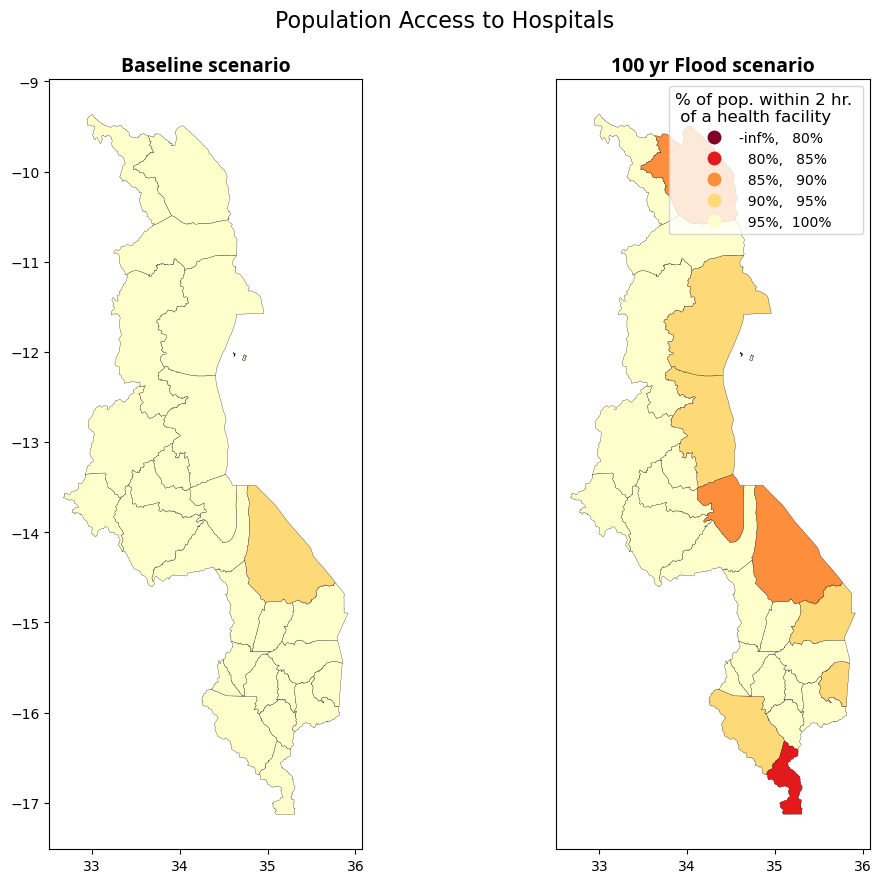

In [129]:
figsize = (12,10)
fig, ax = plt.subplots(1, 2,  figsize = figsize)
fonttitle = {'fontname':'Open Sans','weight':'bold','size':14}

fig.suptitle("Population Access to Hospitals", size = 16, y = 0.95)
ax[0].set_title("Baseline scenario", fontdict=fonttitle)
ax[0].get_xaxis().set_visible(True) # plt.axis('off')
ax[0].get_yaxis().set_visible(True)

ax[1].set_title("100 yr Flood scenario", fontdict=fonttitle)
ax[1].get_xaxis().set_visible(True) # plt.axis('off')
ax[1].get_yaxis().set_visible(False)

res.plot(
    ax=ax[0], column='hospital_pct', cmap='YlOrRd_r', legend=False,
    scheme='user_defined', alpha=1, linewidth=0.2, edgecolor='black', 
    classification_kwds = {'bins': [0.8,0.85,0.9,0.95,1]},
    legend_kwds = {
        'title': "% of pop. within 2 hr. \n of a health facility", 
        'fontsize': 10,
        'fmt': "{:.0%}",
        'title_fontsize': 12
    }
)

res.plot(
    ax=ax[1], column='hospital_pct_flood100', cmap='YlOrRd_r', legend=True,
    scheme='user_defined', alpha=1, linewidth=0.2, edgecolor='black', 
    classification_kwds = {'bins': [0.8,0.85,0.9,0.95,1]},
    legend_kwds = {
        'title': "% of pop. within 2 hr. \n of a health facility", 
        'fontsize': 10,
        'fmt': "{:.0%}",
        'title_fontsize': 12
    }
)
# ctx.add_basemap(ax, source=ctx.providers.Stamen.TerrainLabels, crs='EPSG:4326', zorder=1)
# ctx.add_basemap(ax, source=ctx.providers.Stamen.Terrain, crs='EPSG:4326', zorder=-10, alpha=0.75)

# plt.savefig(os.path.join(scratch_dir, "Health_Access.png"), dpi=150, bbox_inches='tight', facecolor='white')